<a href="https://colab.research.google.com/github/AvichalTrivedi7/IIT-Roorkee_InternshipWork/blob/main/Module_1_(Exercise_1_2)_IITR_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Setup Schedules (similar to exercise 1.1)

import torch
import numpy as np
import matplotlib.pyplot as plt

T = 1000

def linear_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas = torch.linspace(beta_start, beta_end, T)
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)
    return betas, alpha_bar

def cosine_schedule(T, s=0.008):
    t = torch.arange(T + 1)
    f = torch.cos(((t / T + s) / (1 + s)) * torch.pi / 2) ** 2
    alpha_bar = f / f[0]
    alpha_bar = alpha_bar[1:]
    betas = 1 - alpha_bar / torch.cat([alpha_bar[:1], alpha_bar[:-1]])
    betas = betas.clamp(max=0.999)
    return betas, alpha_bar

betas_lin, abar_lin = linear_schedule(T)
betas_cos, abar_cos = cosine_schedule(T)
t_range = torch.arange(1, T + 1)   # t = 1 to 1000

In [2]:
# Compute SNR

def compute_snr(alpha_bar):
    return alpha_bar / (1 - alpha_bar)

snr_lin = compute_snr(abar_lin)
snr_cos = compute_snr(abar_cos)

In [5]:
# Finding the Half-Signal Timestep

def half_signal_timestep(snr_vals):
    # First timestep where SNR drops below 1.0
    below = (snr_vals < 1.0).nonzero(as_tuple=True)[0]
    if len(below) == 0:
        return None
    return below[0].item() + 1   # +1 because t_range starts at 1

t_half_lin = half_signal_timestep(snr_lin)
t_half_cos = half_signal_timestep(snr_cos)

print(f"Linear schedule  - SNR drops below 1.0 at t = {t_half_lin}")
print(f"Cosine schedule  - SNR drops below 1.0 at t = {t_half_cos}")

Linear schedule  - SNR drops below 1.0 at t = 260
Cosine schedule  - SNR drops below 1.0 at t = 497


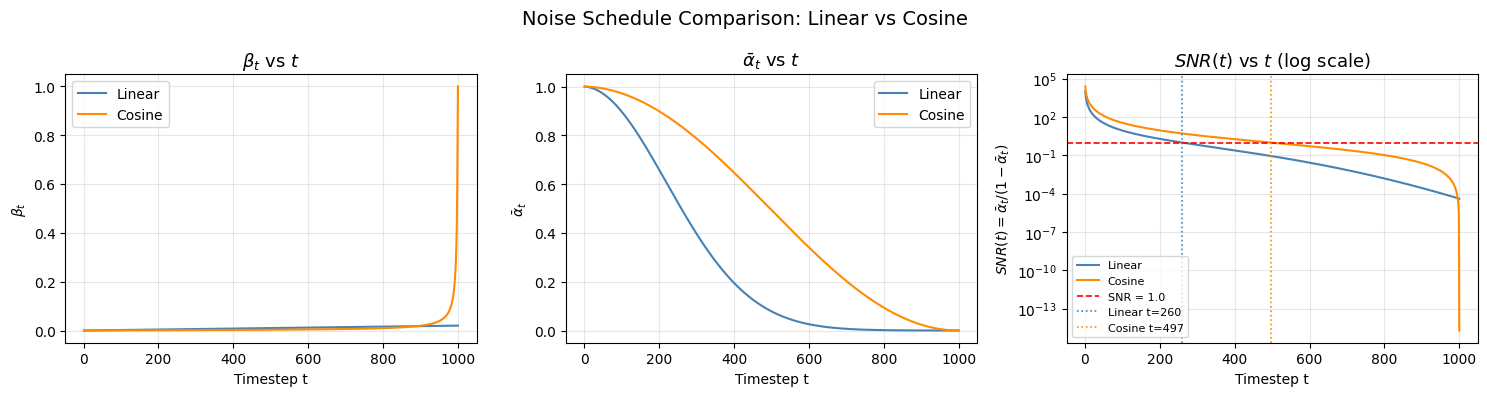

In [4]:
# Three-Panel Plot

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
t_np = t_range.numpy()

# --- Plot 1: β_t vs t ---
axes[0].plot(t_np, betas_lin.numpy(), label='Linear', color='steelblue')
axes[0].plot(t_np, betas_cos.numpy(), label='Cosine', color='darkorange')
axes[0].set_title(r'$\beta_t$ vs $t$', fontsize=13)
axes[0].set_xlabel('Timestep t')
axes[0].set_ylabel(r'$\beta_t$')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Plot 2: ᾱ_t vs t ---
axes[1].plot(t_np, abar_lin.numpy(), label='Linear', color='steelblue')
axes[1].plot(t_np, abar_cos.numpy(), label='Cosine', color='darkorange')
axes[1].set_title(r'$\bar{\alpha}_t$ vs $t$', fontsize=13)
axes[1].set_xlabel('Timestep t')
axes[1].set_ylabel(r'$\bar{\alpha}_t$')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Plot 3: SNR(t) vs t - log scale ---
axes[2].plot(t_np, snr_lin.numpy(), label='Linear', color='steelblue')
axes[2].plot(t_np, snr_cos.numpy(), label='Cosine', color='darkorange')
axes[2].axhline(y=1.0, color='red', linestyle='--', linewidth=1.2, label='SNR = 1.0')

# Mark the half-signal points
axes[2].axvline(x=t_half_lin, color='steelblue', linestyle=':', linewidth=1.2,
                label=f'Linear t={t_half_lin}')
axes[2].axvline(x=t_half_cos, color='darkorange', linestyle=':', linewidth=1.2,
                label=f'Cosine t={t_half_cos}')

axes[2].set_yscale('log')
axes[2].set_title(r'$SNR(t)$ vs $t$ (log scale)', fontsize=13)
axes[2].set_xlabel('Timestep t')
axes[2].set_ylabel(r'$SNR(t) = \bar{\alpha}_t / (1 - \bar{\alpha}_t)$')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3, which='both')

plt.suptitle('Noise Schedule Comparison: Linear vs Cosine', fontsize=14)
plt.tight_layout()
plt.savefig('exercise_1_2.png', dpi=150)
plt.show()

# Observation:

#### 1) Plot 1 - β_t vs t
The linear schedule's β_t is nearly invisible on this scale - it rises gently from 0.0001 to 0.02, which looks like a flat line close to zero. The cosine schedule's β_t is also near zero for almost the entire trajectory, then spikes dramatically to ~1.0 right at t≈1000.

What it means: That spike is the .clamp(max=0.999) kicking in. The cosine schedule's ᾱ_t is defined as a smooth cosine curve, but when you back-derive β_t = 1 − ᾱ_t/ᾱ_{t-1} near t=1000, the denominator gets very small and β_t would theoretically exceed 1. The clamp prevents that, creating the spike. This is expected and correct - it's a known quirk of the cosine schedule derivation that Nichol & Dhariwal explicitly mention.

#### 2) Plot 2 - ᾱ_t vs t
What you observe: Linear decays fast - it crosses 0.5 around t≈260 and reaches near zero by t≈600. Cosine follows a much smoother S-curve, crossing 0.5 around t≈497 and staying above zero well past t=800.

What it means: This is the most important plot. ᾱ_t is the fraction of original signal surviving at timestep t. The linear schedule destroys signal aggressively in the first half of the trajectory. The cosine schedule is nearly symmetric - it spends more time in the "partially noisy" regime, which is exactly where the model does most of its learning.

#### 3) Plot 3 - SNR(t) log scale
What you observe: Both curves start around 10⁵ at t=1 and plummet. The SNR=1.0 line (red dashed) is crossed at t=260 for linear and t=497 for cosine. The cosine curve stays above the linear curve everywhere. The y-axis spans ~18 orders of magnitude (10⁵ to 10⁻¹³), which is why the log scale is essential.

What it means: The linear schedule's signal is already weaker than its noise before the halfway point of the trajectory (t=260 out of 1000). The cosine schedule nearly doubles this useful region to t=497. Every timestep to the right of these vertical lines is a timestep where noise dominates - the model is effectively learning nothing useful from those gradient updates.

# Interpretation:
#### The three plots together show that the linear and cosine schedules differ not just in shape but in how much of the 1000-step trajectory is actually useful for training. The linear schedule's ᾱ_t collapses early, pushing the SNR below 1.0 at t=260 - meaning 74% of all training timesteps occur in a noise-dominated regime where the signal is already unrecoverable. The cosine schedule delays this crossover to t=497, nearly doubling the proportion of the trajectory where the model receives informative gradient signal. The β_t spike at the end of the cosine schedule is a known numerical artifact of back-deriving per-step noise from a smoothly-defined cumulative curve, not a design flaw.

####This analysis is the direct empirical basis for LDAE's SNR-weighted loss (Equation 15): since the raw loss L_t weighted uniformly would assign equal importance to all 1000 timesteps, the SNR weighting λ_t ∝ SNR(t)^γ corrects this by concentrating gradient updates on the **t < 497 region where the signal is still intact and representation learning is actually possible**